In [4]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from scripts_analysis.regression import get_mixed_model_coefficients_random
from notebooks.visualization import plot_effect_for_key_regressor_one_value

In [ ]:
target_path = './data/human_data/Experiment1_8_choice'

accuracy_array = np.load(os.path.join(target_path, 'acc_value.npy'))
FAR_array = np.load(os.path.join(target_path, 'far_value.npy'))
confidence_array = np.load(os.path.join(target_path, 'confidence_stim_value.npy'))
rt_array = np.load(os.path.join(target_path, 'rt_value.npy'))
bias_array = np.load(os.path.join(target_path, 'bias_value.npy'))

n_subjects = accuracy_array.shape[0]
n_trials_per_subject = accuracy_array.shape[1] if len(accuracy_array.shape) > 1 else 1

df = pd.DataFrame({
    'subject_id': np.repeat(np.arange(0, n_subjects), n_trials_per_subject),
    'accuracy': accuracy_array.flatten(),
    'confidence': confidence_array.flatten(), 
    'FAR': FAR_array.flatten(),
    'rt': rt_array.flatten(),

})
df['subject_idx'] = df['subject_id'].astype('category').cat.codes
n_subjects = df['subject_idx'].nunique()
scaler = StandardScaler()
df['FAR_z'] = scaler.fit_transform(df[['FAR']])
df['accuracy_z'] = scaler.fit_transform(df[['accuracy']])
df['confidence_z'] = scaler.fit_transform(df[['confidence']])
df['rt_z'] = scaler.fit_transform(df[['rt']])

bias_terms = ['FAR_z']
acc_terms = ['accuracy_z']
rt_term = ['rt_z']

dependent_var = 'confidence_z'
regressors = bias_terms + acc_terms + rt_term

coeffs_list, results = get_mixed_model_coefficients_random(df, dependent_var, regressors,print_summary=False)

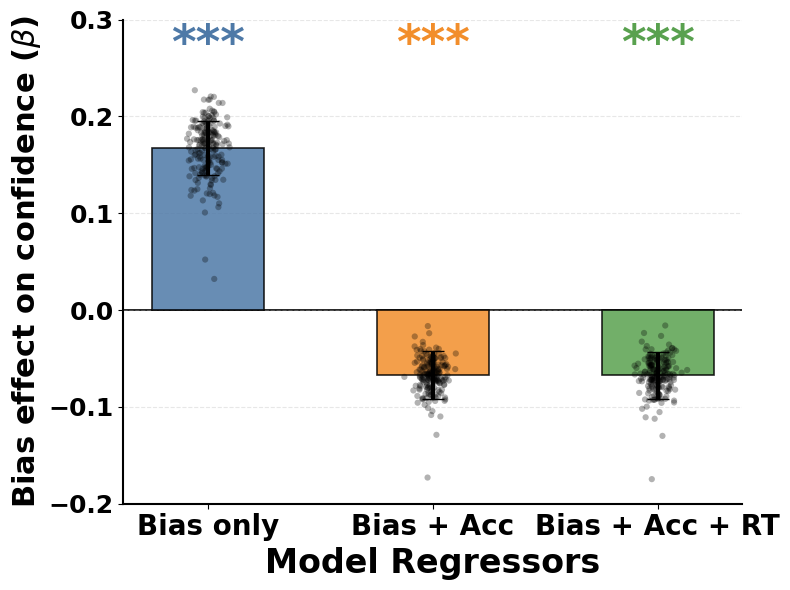

In [ ]:
nature_colors = ['#4E79A7', '#F28E2B', '#59A14F']

plot_effect_for_key_regressor_one_value(
    coeffs_list=coeffs_list,
    model_results=results,
    bar_color=nature_colors, 
    labels=['Bias only', 'Bias + Acc', 'Bias + Acc + RT'],
    title=None,
    ylim=[-0.2, 0.3],
    figsize=(8, 6),
    bar_width=0.5,
    star_height=0.25
)